# Preamble

## Imports & Path

In [1]:
%cd ..

/home/aru/Work/shome2023notebook


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, barnard_exact
from itertools import combinations

In [3]:
sns.set_theme(
    context="talk",
    palette="colorblind",
    style="whitegrid",
)

## Data Loading & Prep


In [4]:
data = pd.read_csv("data/shome2023notebook/annotations.csv")
data.head()

,notebook,stmt,source,CALL,CGH,CKG,EC,Intent,Stage,Notes,Type
0,data/assert_notebooks/lepmik/meta-reinforcemen...,np.unique(env._s_hist[:-1][np.diff(env._s_hist...,GH,-1,-2.0,NaN,NaN,EXP,EVAL,RL context. Diagnostic to identify which state...,COMPUTE
1,data/assert_notebooks/dhuynh95/cryptotree/nbs/...,"(comparator.weight.data, comparator.bias.data)",GH,117,-2.0,NaN,NaN,EXP,EVAL,Check learned weights and bias of model.,INSPECT
2,data/assert_notebooks/nikohou/LoadLanguageMode...,assert dim % 2 == 0,GH,992,-2.0,NaN,NaN,VAL,MODEL,Defined inside `__init__` method of a neural n...,EQ
3,data/assert_notebooks/EricCousineau-TRI/repro/...,assert activated.ndim > 1,GH,1021,-2.0,NaN,NaN,VAL,MODEL,"Ensure activation tensor is a batch (2D), not ...",SHAPE
4,data/assert_notebooks/H-E-L-P/XID_plus/docs/bu...,"plt.plot(test_x, test_y, 'ro', alpha=0.5)",GH,614,-2.0,NaN,NaN,EXP,EVAL,Visually inspect actual vs. predictions of the...,INSPECT


Collapse the "DOC" intent into "EXP". We have a really small number of sample and ultimately, they are last cell statements so fall under "EXP" anyway.

In [5]:
data.loc[data["Intent"] == "DOC", "Intent"] = "EXP"

## Helper Functions

In [6]:
def annot_count_with_percent(ax) -> None:
    """Annotate each bar with count and percentage relative to hue size."""
    for container in ax.containers:
        total = sum(p.get_height() for p in container)
        labels = [
            f"{int(p.get_height())} ({100 * p.get_height() / total:.1f}%)"
            for p in container
        ]
        ax.bar_label(container, labels=labels, fontsize=10.0)

# Function intent of validation statements (Dimension A)

## Top-level intent split (VAL vs EXP vs DOC)

In [7]:
def counts(data, col):
    counts = data[col].value_counts()
    pct = data[col].value_counts(normalize=True).mul(100).round(1)
    return pd.concat([counts, pct], axis=1, keys=["count", "pct"])

In [8]:
pd.concat({
    "Total": counts(data, "Intent"),
    "GH": counts(data[data["source"] == "GH"], "Intent"),
    "KG": counts(data[data["source"] == "KG"], "Intent"),
})

count   pct
      Intent             
Total EXP       692  84.9
      VAL       123  15.1
GH    EXP       263  68.8
      VAL       119  31.2
KG    EXP       429  99.1
      VAL         4   0.9

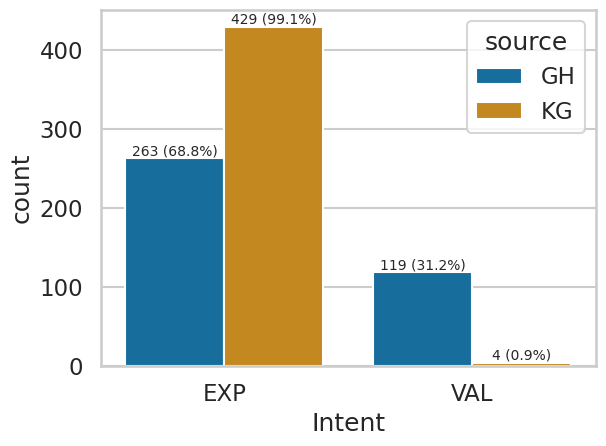

In [9]:
ax = sns.countplot(
    data=data,
    x='Intent',
    order=data["Intent"].value_counts().index,
    hue='source'
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent.pdf")

Are the two populations siginificantly different from one another?

In [11]:
observed = pd.crosstab(data["source"], data["Intent"])
res = barnard_exact(observed)
res.pvalue

np.float64(1.0358075145754753e-22)

Intent is not independant of the source

## EXP breakdown

In [12]:
d = data[data["Intent"] == "EXP"]

In [13]:
pd.concat({
    "Total": counts(d, "Type"),
    "GH": counts(d[d["source"] == "GH"], "Type"),
    "KG": counts(d[d["source"] == "KG"], "Type"),
})

count   pct
      Type                
Total INSPECT    296  42.8
      COMPUTE    185  26.7
      STRUCT     126  18.2
      STATS       78  11.3
      DOC          7   1.0
GH    INSPECT    115  43.7
      COMPUTE     82  31.2
      STRUCT      40  15.2
      STATS       20   7.6
      DOC          6   2.3
KG    INSPECT    181  42.2
      COMPUTE    103  24.0
      STRUCT      86  20.0
      STATS       58  13.5
      DOC          1   0.2

Are the populations significantly different?

In [18]:
observed = pd.crosstab(d["source"], d["Type"])
res = chi2_contingency(observed)
res.pvalue

np.float64(0.0018126164921117977)

Is the presence of "DOC" influencing the p-value?

In [21]:
d = d[d["Type"] != "DOC"]
d["Type"].value_counts()

Type
INSPECT    296
COMPUTE    185
STRUCT     126
STATS       78
Name: count, dtype: int64

In [22]:
observed = pd.crosstab(d["source"], d["Type"])
res = chi2_contingency(observed)
res.pvalue

np.float64(0.01570672734495773)

Yes! DOC is useless, there are only 7 observations and they don't add anything to the analysis.

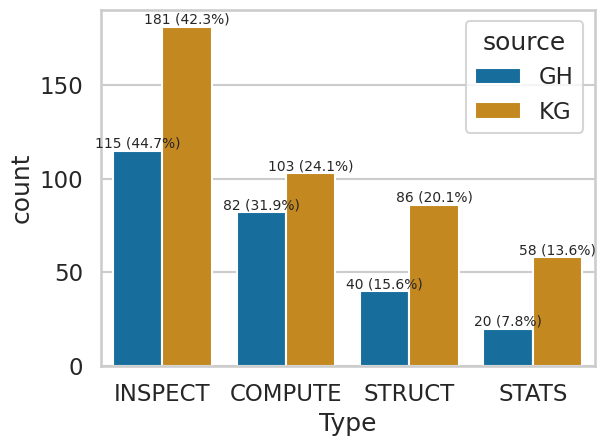

In [23]:
ax = sns.countplot(
    data=d,
    x="Type",
    order=d["Type"].value_counts().index,
    hue="source",
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()

## VAL breakdown
GH focused since KG only contains 4 assertions.

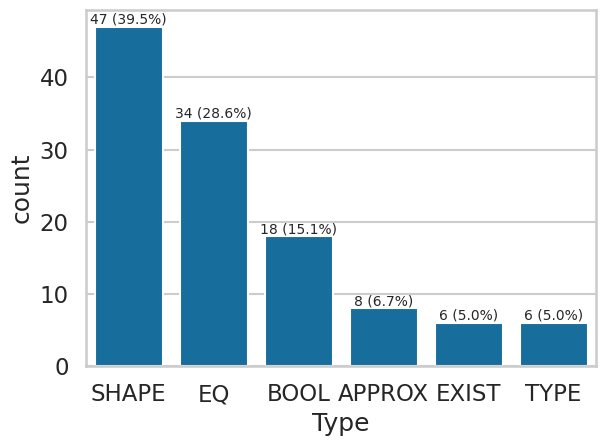

In [8]:
d = data[data["Intent"] == "VAL"]
ax = sns.countplot(
    data=d,
    x="Type",
    order=d["Type"].value_counts().index,
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()

# ML pipeline stage distribution (Dimension B)

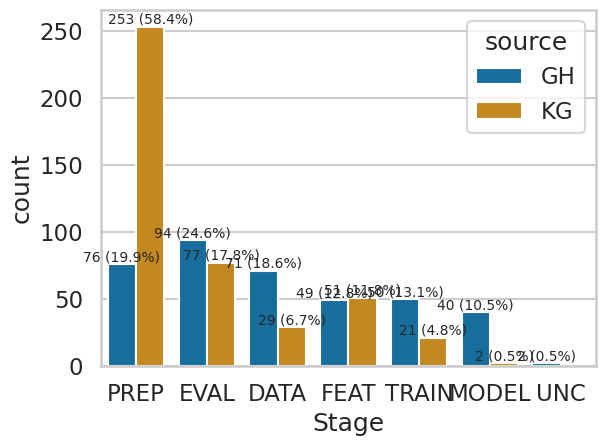

In [9]:
ax = sns.countplot(
    data=data,
    x="Stage",
    hue="source",
    order=data["Stage"].value_counts().index,
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()